Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Loading the Dataset

In [ ]:
#loading the dataset to a PandaDataframe
credit_card_data = pd.read_csv('/content/credit_score.csv')

In [ ]:
#first 5 rows of dataset
credit_card_data.head()

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


In [ ]:
credit_card_data.tail()

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
995,CZQHJC9HDH,328892,1465066,5501471,4.4546,16.7273,3.7551,16701,10132,0.6067,...,0.2041,0.0543,High,1,1,1,1,1,418,0
996,CZRA4MLB0P,81404,88805,680837,1.0909,8.3637,7.6667,5400,1936,0.3585,...,0.8333,0.1087,No,1,0,0,1,0,589,1
997,CZSOD1KVFX,0,42428,30760,3.2379,8.1889,0.7250,0,0,0.8779,...,0.2500,0.3448,No,1,0,0,1,0,499,0
998,CZWC76UAUT,36011,8002,604181,0.2222,16.7777,75.5037,1993,1271,0.6377,...,5.0002,0.0662,No,1,1,0,1,0,507,0
999,CZZV5B3SAL,44266,309859,44266,6.9999,1.0000,0.1429,1574,1264,0.8030,...,0.1587,1.1111,No,1,0,0,1,0,657,0


In [ ]:
#dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 87 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  1000 non-null   object 
 1   INCOME                   1000 non-null   int64  
 2   SAVINGS                  1000 non-null   int64  
 3   DEBT                     1000 non-null   int64  
 4   R_SAVINGS_INCOME         1000 non-null   float64
 5   R_DEBT_INCOME            1000 non-null   float64
 6   R_DEBT_SAVINGS           1000 non-null   float64
 7   T_CLOTHING_12            1000 non-null   int64  
 8   T_CLOTHING_6             1000 non-null   int64  
 9   R_CLOTHING               1000 non-null   float64
 10  R_CLOTHING_INCOME        1000 non-null   float64
 11  R_CLOTHING_SAVINGS       1000 non-null   float64
 12  R_CLOTHING_DEBT          1000 non-null   float64
 13  T_EDUCATION_12           1000 non-null   int64  
 14  T_EDUCATION_6            

In [ ]:
#checking the number of missing values in each column
credit_card_data.isnull().sum()

,0
CUST_ID,0
INCOME,0
SAVINGS,0
DEBT,0
R_SAVINGS_INCOME,0
...,...
CAT_MORTGAGE,0
CAT_SAVINGS_ACCOUNT,0
CAT_DEPENDENTS,0
CREDIT_SCORE,0


In [ ]:
#distribution of target variable
credit_card_data['DEFAULT'].value_counts()

,count
DEFAULT,
0,716
1,284


0 --> No Default

1 --> Default

In [ ]:
#statistical measure of the data
credit_card_data.describe()

,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,R_CLOTHING_INCOME,...,R_EXPENDITURE_INCOME,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,121610.019000,4.131896e+05,7.907180e+05,4.063477,6.068449,5.867252,6822.401000,3466.320000,0.454848,0.055557,...,0.943607,0.913340,0.605276,0.944000,0.236000,0.173000,0.993000,0.15000,586.712000,0.284000
std,113716.699591,4.429160e+05,9.817904e+05,3.968097,5.847878,16.788356,7486.225932,5118.942977,0.236036,0.037568,...,0.168989,1.625278,1.299382,0.230037,0.424835,0.378437,0.083414,0.35725,63.413882,0.451162
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003400,...,0.666700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000
25%,30450.250000,5.971975e+04,5.396675e+04,1.000000,1.454500,0.206200,1084.500000,319.500000,0.263950,0.029700,...,0.833300,0.158700,0.100000,1.000000,0.000000,0.000000,1.000000,0.00000,554.750000,0.000000
50%,85090.000000,2.738505e+05,3.950955e+05,2.545450,4.911550,2.000000,4494.000000,1304.000000,0.468850,0.046800,...,0.909100,0.327950,0.178600,1.000000,0.000000,0.000000,1.000000,0.00000,596.000000,0.000000
75%,181217.500000,6.222600e+05,1.193230e+06,6.307100,8.587475,4.509600,10148.500000,4555.500000,0.626300,0.069400,...,1.000000,0.833300,0.588200,1.000000,0.000000,0.000000,1.000000,0.00000,630.000000,1.000000
max,662094.000000,2.911863e+06,5.968620e+06,16.111200,37.000600,292.842100,43255.000000,39918.000000,1.058300,0.251700,...,2.000200,10.009900,10.005300,1.000000,1.000000,1.000000,1.000000,1.00000,800.000000,1.000000


Data Preprocessing

In [ ]:
credit_card_data.select_dtypes(include='object').columns

Index(['CUST_ID', 'CAT_GAMBLING'], dtype='object')

In [ ]:
# Remove Customer ID
credit_card_data = credit_card_data.drop('CUST_ID', axis=1)

# Convert CAT_GAMBLING to numbers
credit_card_data['CAT_GAMBLING'] = credit_card_data['CAT_GAMBLING'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [ ]:
credit_card_data.dtypes

,0
INCOME,int64
SAVINGS,int64
DEBT,int64
R_SAVINGS_INCOME,float64
R_DEBT_INCOME,float64
...,...
CAT_MORTGAGE,int64
CAT_SAVINGS_ACCOUNT,int64
CAT_DEPENDENTS,int64
CREDIT_SCORE,int64


Correlation Heatmap

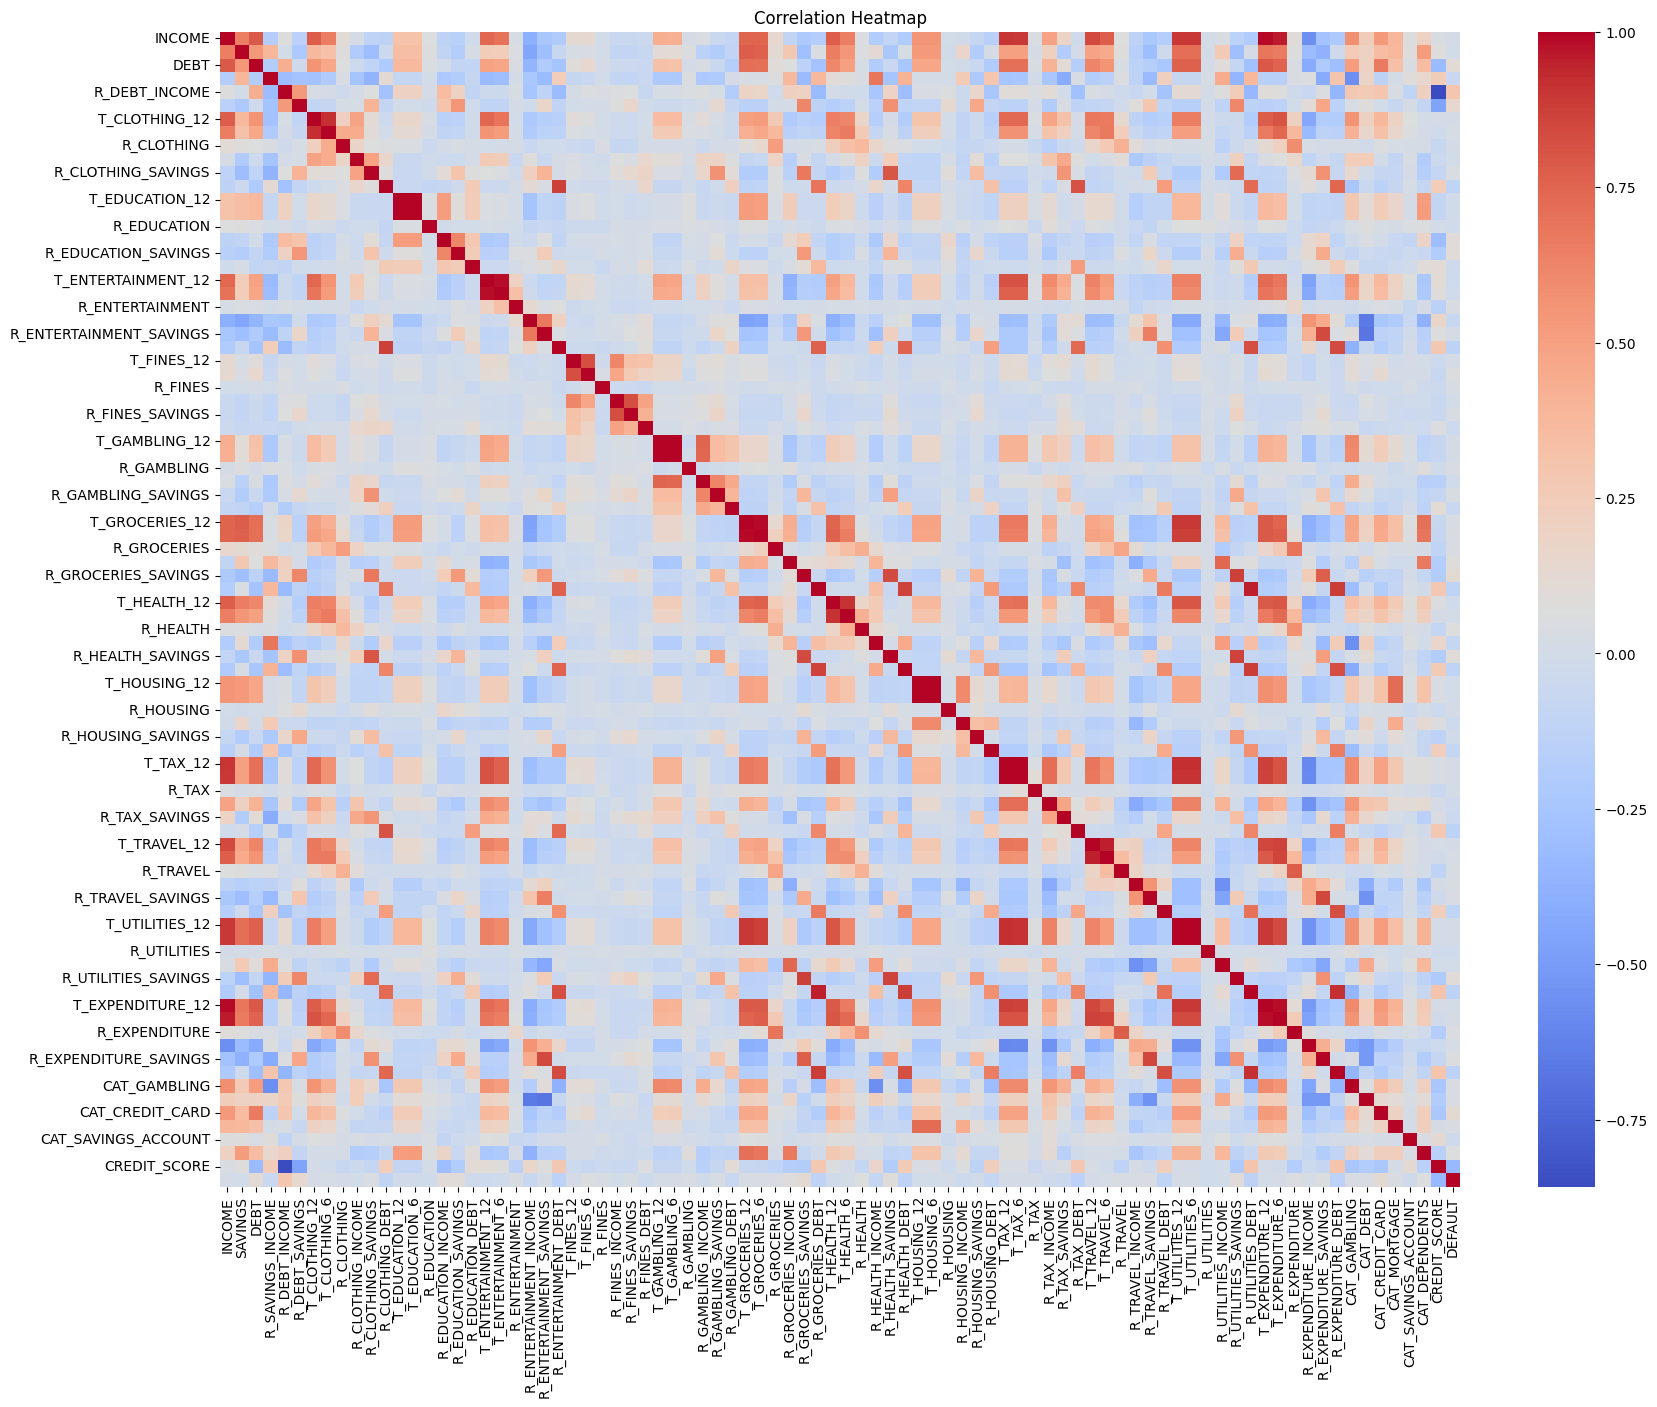

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,15))
sns.heatmap(credit_card_data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Splitting the data into Features and Targets

In [ ]:
X = credit_card_data.drop(columns='DEFAULT', axis = 1)
Y = credit_card_data['DEFAULT']

In [ ]:
print(X)

     INCOME  SAVINGS     DEBT  R_SAVINGS_INCOME  R_DEBT_INCOME  \
0     33269        0   532304            0.0000        16.0000   
1     77158    91187   315648            1.1818         4.0909   
2     30917    21642   534864            0.7000        17.3000   
3     80657    64526   629125            0.8000         7.8000   
4    149971  1172498  2399531            7.8182        16.0000   
..      ...      ...      ...               ...            ...   
995  328892  1465066  5501471            4.4546        16.7273   
996   81404    88805   680837            1.0909         8.3637   
997       0    42428    30760            3.2379         8.1889   
998   36011     8002   604181            0.2222        16.7777   
999   44266   309859    44266            6.9999         1.0000   

     R_DEBT_SAVINGS  T_CLOTHING_12  T_CLOTHING_6  R_CLOTHING  \
0            1.2000           1889           945      0.5003   
1            3.4615           5818           111      0.0191   
2           24.

In [ ]:
print(Y)

0      1
1      0
2      1
3      0
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: DEFAULT, Length: 1000, dtype: int64


Splitting the data into training data and testing data

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X, Y , test_size = 0.2 , stratify =Y , random_state = 42)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(1000, 85) (800, 85) (200, 85)


Check how many NaNs are left

In [ ]:
print(credit_card_data.isnull().sum().sum())

620


Fix CAT_GAMBLING

In [ ]:
credit_card_data['CAT_GAMBLING'] = credit_card_data['CAT_GAMBLING'].fillna(0)

Verify Again

In [ ]:
print(credit_card_data.isnull().sum().sum())

0


Recreate X and y

In [ ]:
X = credit_card_data.drop('DEFAULT', axis=1)
y = credit_card_data['DEFAULT']

Recreate train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scale Again

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Again

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Make Predictions

In [ ]:
y_pred = model.predict(X_test)

Check Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.73


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[131  15]
 [ 39  15]]


Visualize it:

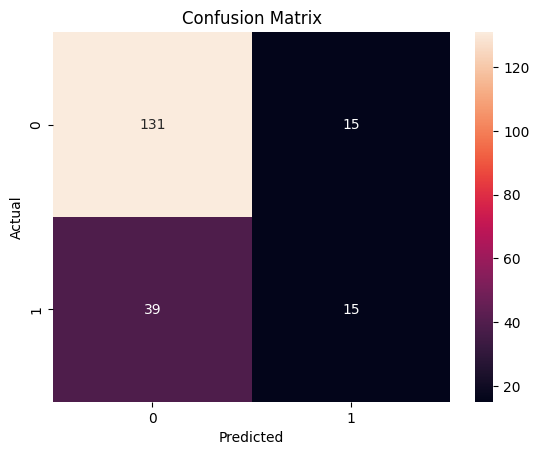

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       146
           1       0.50      0.28      0.36        54

    accuracy                           0.73       200
   macro avg       0.64      0.59      0.59       200
weighted avg       0.70      0.73      0.70       200



ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.6617199391171995


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.75      0.91      0.82       146
           1       0.41      0.17      0.24        54

    accuracy                           0.71       200
   macro avg       0.58      0.54      0.53       200
weighted avg       0.66      0.71      0.66       200



Then handle class imbalance

Your dataset is:

Non-default: 716

Default: 284

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.74      0.88      0.81       146
           1       0.35      0.17      0.23        54

    accuracy                           0.69       200
   macro avg       0.54      0.53      0.52       200
weighted avg       0.63      0.69      0.65       200



Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82       146
           1       0.47      0.26      0.33        54

    accuracy                           0.72       200
   macro avg       0.62      0.57      0.58       200
weighted avg       0.68      0.72      0.69       200



Saving the model

In [ ]:
import joblib

joblib.dump(model, 'credit_card_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Logistic Regression model saved successfully")

Logistic Regression model saved successfully
